# Test de normalité de Shapiro-Wilk
**OUSSENI Bicharati — KOBA Kami**

In [6]:
base_url = "https://raw.githubusercontent.com/shapiroMIGS/shapiro-wilk/main/data_"

In [7]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

from scipy import stats
import pandas as pd

import scipy.stats as stats
from scipy.stats import norm

import os
os.makedirs("images", exist_ok=True)


## **1. Les fonctions**

### Fonctions principales du test

Nous définissons ici les quatre fonctions qui constituent le cœur du test de Shapiro-Wilk :

- **`Matrice_V`** : simule un grand nombre d'échantillons normaux et en estime le vecteur des espérances $m$ et la matrice de covariance $V$ des statistiques d'ordre.
- **`coef_a_robuste`** : calcule les coefficients $a = m/\|m\|$ sans inverser $V$, ce qui évite les instabilités numériques pour les grands $n$.
- **`Statistique_W`** : calcule la statistique $W = b^2/S^2$ à partir d'un échantillon et des coefficients $a$.
- **`calculer_w_min`** : calcule la borne inférieure théorique de $W$ donnée par le Lemme 3 de Shapiro & Wilk (1965).

In [8]:
#Construction de m et V

def Matrice_V(n, Nsim=5000):
    Z = []
    for _ in range(Nsim):
        z=np.random.normal(0, 1, n)
        Z.append(np.sort(z))

    Z = np.array(Z)

    m = np.mean(Z, axis=0)          # espérance
    V = np.cov(Z, rowvar=False)     # covariance

    return m, V, Z

#Calcul des coefficients a

def coef_a(m, V): #Non robuste plus difficile d'inverser la matrice V lorsque n devient tros grand
    V_inv=np.linalg.inv(V)
    b=V_inv@m
    a = b/np.sqrt(b@b)#Normalisation
    return a

#Calcule les poids 'a' de manière robuste c.f. article 2
def coef_a_robuste(m):
    a=m/np.sqrt(m@m) #Normalisation
    return a


# Statistique W
def Statistique_W(x, a):
  y=np.sort(x)
  y_bar=np.mean(x)

  num=(a@y)**2
  den=np.sum((y-y_bar)**2)

  return num/den


# La valeur minimale de la statistique W
def calculer_w_min(n, a_max):
    """
    Lemme 3 page 593
    n: taille de l'échantillon
    a1: premier coefficient de la table de Shapiro-Wilk pour n qui correspont a a[-1] dans notre vecteur
    """
    w_min=(n*(a_max**2))/(n - 1)
    return w_min


Ces fonctions seront réutilisées dans toutes les sections suivantes.
Les coefficients $a$ et les valeurs de $W$ simulées seront sauvegardés
dans des fichiers texte pour éviter de les recalculer à chaque exécution.

## **2. Génération et sauvegarde des valeurs de a et W**

### **Génération et sauvegarde des fichiers de simulation**

Cette cellule génère les fichiers de simulation pour chaque taille $n$ de 3 à 100.
Pour chaque $n$, on calcule les coefficients $a$ et on simule $N_{\text{sim}} = 10^6$
valeurs de la statistique $W$ sous $H_0$.

> **Note :** Cette cellule a déjà été exécutée et les fichiers sont disponibles
> sur GitHub. Il n'est donc pas nécessaire de la relancer.


In [ ]:
import time

np.random.seed(42) # Pour avoir le même environnement peut import le moment de l'execution


tailles= range(3, 101)
Nsim = 1000000

print(f"DÉMARRAGE DE LA GÉNÉRATION (n=3 à n=100)")


temps_debut= time.time()

for n in tailles:
  # Calculer les a et les sauvegarder en txt
    m, V, Z = Matrice_V(n, Nsim=Nsim)
    a= coef_a_robuste(m)
    np.savetxt(f"a_n{n}.txt", a, fmt="%.6e")

    # Générer les valeurs de W et les sauvegarder en txt
    W_values = []
    for i in range(Nsim):
      W = Statistique_W(Z[i], a)
      W_values.append(W)
    W_values = np.array(W_values)
    np.savetxt(f"W_n{n}.txt", W_values, fmt="%.6e")


    if n % 10 == 0 or n == 3:
        print(f"n = {n:2d} terminé.")


temps_fin = time.time()
duree_secondes = temps_fin - temps_debut
duree_minutes = duree_secondes / 60

print("FIN DE LA GÉNÉRATION")

DÉMARRAGE DE LA GÉNÉRATION (n=3 à n=100)


NameError: name 'Matrice_V' is not defined

Les fichiers générés sont disponibles à l'adresse suivante :
[https://github.com/shapiroMIGS/shapiro-wilk/tree/main/data_](https://github.com/shapiroMIGS/shapiro-wilk/tree/main/data_)

Le temps d'exécution total était d'environ **56 minutes** pour $n = 3$ à $n = 100$
avec $N_{\text{sim}} = 10^6$ simulations.

## **3. Analyse graphique**

### **Outils de visualisation**

Avant d'appliquer le test, il est utile de visualiser les données pour avoir
une première idée de leur distribution. Nous définissons deux fonctions graphiques :

- **`tracer_histogramme`** : trace la distribution des données sous forme d'histogramme.
- **`tracer_qq_plot`** : trace le diagramme Quantile-Quantile (Q-Q plot) qui compare
les quantiles empiriques des données aux quantiles théoriques d'une loi normale.
Si les points s'alignent sur la droite rouge, les données sont compatibles avec la normalité.

In [9]:
# L'histogramme:

def tracer_histogramme(donnees, bins=10, densite=False, titre="Histogramme", xlabel="Valeurs", ylabel="Fréquence"):
    plt.figure()

    plt.hist(donnees, bins=bins, density=densite, color='skyblue', edgecolor='black')

    plt.title(titre)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


#Le q-q plot

def tracer_qq_plot(donnees, titre="Q-Q Plot de Normalité"):
    """
    Trace le diagramme Quantile-Quantile pour évaluer visuellement
    l'alignement des données avec une distribution normale.
    """
    plt.figure(figsize=(7, 5))

    # probplot génère les points bleus et la droite rouge automatiquement
    stats.probplot(donnees, dist="norm", plot=plt)

    plt.title(titre)
    plt.xlabel("Quantiles théoriques (Loi Normale)")
    plt.ylabel("Quantiles empiriques (Données triées)")
    plt.grid(True, alpha=0.3)
    plt.show()

Ces deux graphiques sont complémentaires : l'histogramme donne une vue globale
de la forme de la distribution, tandis que le Q-Q plot permet de détecter
visuellement les écarts à la normalité, notamment dans les queues de distribution.

## **4. Analyse de la distribution de W**

### **Distribution de $W$ sous $H_0$ pour différentes tailles d'échantillon**

Pour comprendre le comportement de la statistique $W$ sous l'hypothèse nulle,
nous simulons sa distribution pour plusieurs tailles $n \in \{5, 10, 20, 30\}$.

Pour chaque $n$, on trace deux graphiques :
- **La fonction de répartition empirique** $\hat{F}_N(W)$ : montre comment les valeurs
de $W$ se répartissent entre sa borne inférieure théorique et $1$.
- **La densité estimée par noyau (KDE)** : donne une vision lisse de la distribution de $W$.

La ligne pointillée noire indique la **borne inférieure théorique** $W_{\min} = \frac{n a_1^2}{n-1}$.

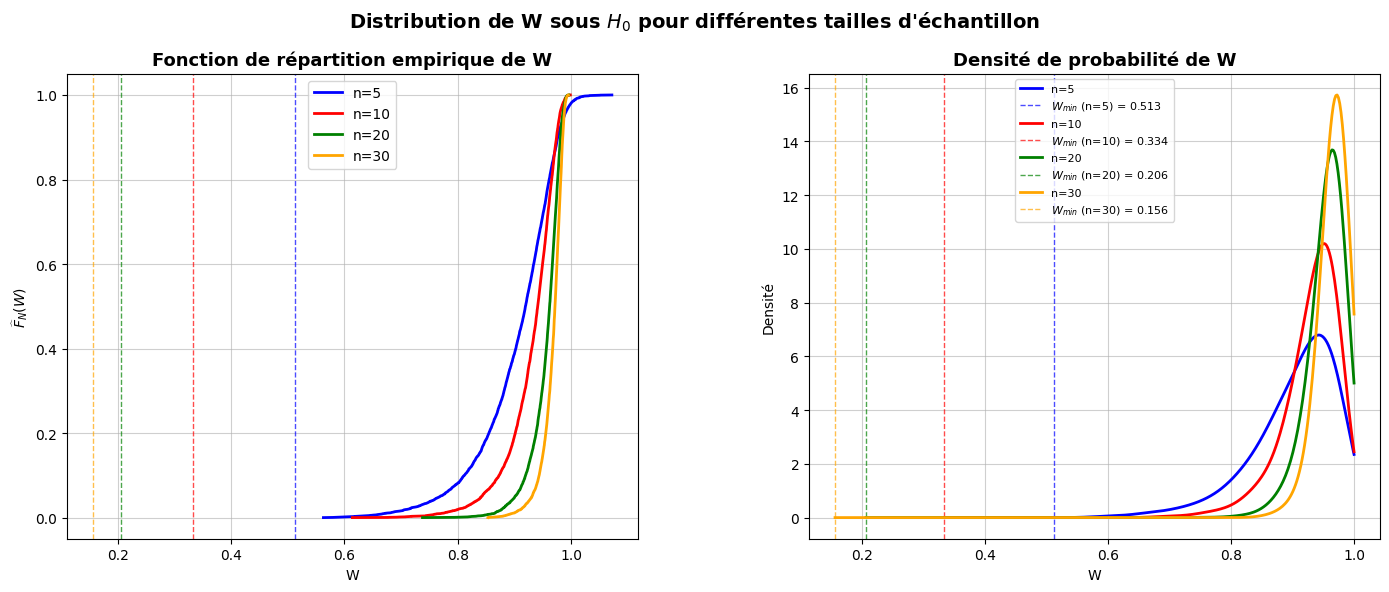

In [10]:
from sklearn.neighbors import KernelDensity

tailles = [5, 10, 20, 30]
Nsim = 50000
bandwidth = 0.02

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors= ["blue", "red", "green", "orange"]

for n, color in zip(tailles, colors):
    try:
        a = np.loadtxt(f"{base_url}/a_n{n}.txt")
        W_simules = np.loadtxt(f"{base_url}/W_n{n}.txt")[:Nsim]
    except OSError:
        print(f"Erreur : fichiers manquants pour n={n}.")
        continue


# Minimum théorique
    w_min_theorique = (n * a[-1]**2) / (n - 1)
    # Fonction de répartition empirique
    W_triee = np.sort(W_simules)
    N       = len(W_triee)
    Fn      = np.arange(1, N + 1) / N

    axes[0].plot(W_triee, Fn, color=color, linewidth=2, label=f"n={n}")
    axes[0].axvline(w_min_theorique, color=color, linestyle='--', linewidth=1, alpha=0.7)

    # Densité KDE
    x       = np.linspace(w_min_theorique, 1.0, 400).reshape(-1, 1)
    kde     = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(W_simules.reshape(-1, 1))
    densite = np.exp(kde.score_samples(x))

    axes[1].plot(x.ravel(), densite, color=color, linewidth=2, label=f"n={n}")
    axes[1].axvline(w_min_theorique, color=color, linestyle='--', linewidth=1,
                    alpha=0.7, label=f"$W_{{min}}$ (n={n}) = {w_min_theorique:.3f}")

# Mise en forme graphique 1
axes[0].set_title("Fonction de répartition empirique de W", fontsize=13, fontweight='bold')
axes[0].set_xlabel("W")
axes[0].set_ylabel(r"$\widehat{F}_N(W)$")
axes[0].legend()
axes[0].grid(True, alpha=0.6)

# Mise en forme graphique 2
axes[1].set_title("Densité de probabilité de W", fontsize=13, fontweight='bold')
axes[1].set_xlabel("W")
axes[1].set_ylabel("Densité")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.6)

plt.suptitle("Distribution de W sous $H_0$ pour différentes tailles d'échantillon",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.savefig("images/distribution_de_W.png", dpi=300, bbox_inches='tight')
plt.show()

**Observations :**

- Pour les petits échantillons ($n = 5$), la distribution de $W$ est très étalée
et la borne inférieure est relativement haute.
- Lorsque $n$ augmente, la distribution se concentre de plus en plus près de $1$
et la courbe devient plus raide.
- La borne inférieure $W_{\min}$ diminue avec $n$, ce qui signifie que $W$ peut
prendre des valeurs de plus en plus petites pour les grands échantillons.

### **Densité de $W$ pour différentes lois**

Pour évaluer la capacité du test à détecter la non-normalité, nous comparons
la distribution de $W$ sous $H_0$ (loi normale) avec celle obtenue sous
plusieurs lois alternatives, pour $n = 20$ :

- Loi **Exponentielle** : asymétrique à droite
- Loi **Uniforme** : symétrique à queue courte
- Loi **de Laplace** : symétrique à queue lourde
- Loi du **Khi-deux** : asymétrique

Plus la densité d'une loi est décalée vers la gauche par rapport à la normale,
plus le test sera efficace pour la détecter.

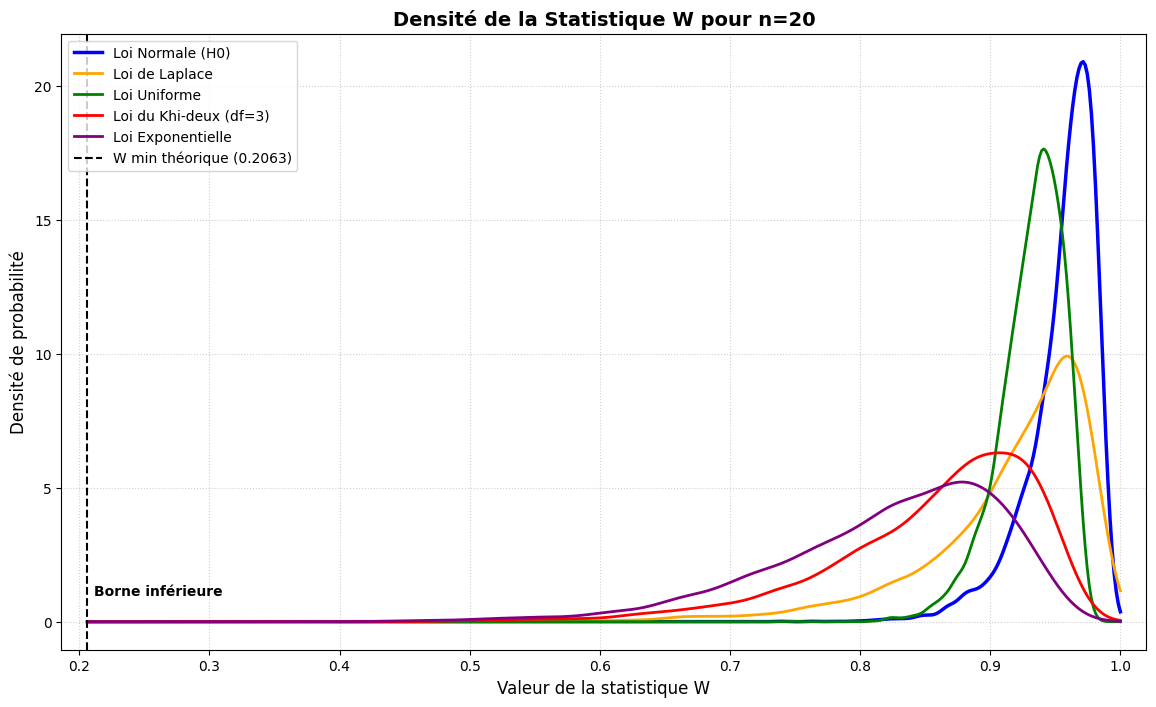

In [11]:
from scipy.stats import gaussian_kde
# Paramètres
n = 20
Nsim = 5000

#Chargement des données

try:
  a = np.loadtxt(f"{base_url}/a_n{n}.txt")
  scores_normale = np.loadtxt(f"{base_url}/W_n{n}.txt")[:Nsim]

except OSError:
  print(f"Erreur: Les fichiers pour n={n} sont introuvables.")
  raise #Arrêt si fichier manquant

# Calcul de la valeur minimal de w
w_minimal = calculer_w_min(n, a[-1]) # Elle est égale à 0.21

#Simulation des autres lois
scores_exponentielle = []
scores_uniforme = []
scores_laplace = []
scores_khi_deux = []

# Boucle méthode de Monte-Carlo
for _ in range(Nsim):

    # On génère les données
    x_expo = np.random.exponential(1, n)
    x_uni  = np.random.uniform(0, 1, n)
    x_lap  = np.random.laplace(0, 1, n)
    x_khi  = np.random.chisquare(df=3, size=n)

    # Calcul et stockage de la statistique W
    scores_exponentielle.append(Statistique_W(x_expo, a))
    scores_uniforme.append(Statistique_W(x_uni, a))
    scores_laplace.append(Statistique_W(x_lap, a))
    scores_khi_deux.append(Statistique_W(x_khi, a))

# Calcul des densités lisses(Kernel Density Estimation)
kde_norm = gaussian_kde(scores_normale)
kde_expo = gaussian_kde(scores_exponentielle)
kde_uni  = gaussian_kde(scores_uniforme)
kde_lap  = gaussian_kde(scores_laplace)
kde_khi  = gaussian_kde(scores_khi_deux)


# Tracé du graphique
x = np.linspace(w_minimal, 1.0, 500)
plt.figure(figsize=(14, 8))


plt.plot(x, kde_norm(x), label="Loi Normale (H0)",       color="blue",   linewidth=2.5)
plt.plot(x, kde_lap(x),  label="Loi de Laplace",         color="orange", linewidth=2)
plt.plot(x, kde_uni(x),  label="Loi Uniforme",           color="green",  linewidth=2)
plt.plot(x, kde_khi(x),  label="Loi du Khi-deux (df=3)", color="red",    linewidth=2)
plt.plot(x, kde_expo(x), label="Loi Exponentielle",      color="purple", linewidth=2)

plt.axvline(w_minimal, color='black', linestyle='--', linewidth=1.5,
            label=f"W min théorique ({w_minimal:.4f})")

plt.text(w_minimal + 0.005, 1, f"Borne inférieure",
         color='black', fontweight='bold', fontsize=10)

plt.title(f"Densité de la Statistique W pour n={n}", fontsize=14, fontweight='bold')
plt.xlabel("Valeur de la statistique W", fontsize=12)
plt.ylabel("Densité de probabilité", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

# Limitation de l'axe X
plt.xlim(w_minimal - 0.02, 1.02)

# Sauvegarde
plt.savefig("densites_superposees.png", dpi=300, bbox_inches='tight')

plt.show()

### **Convergence de $W$ lorsque $n$ augmente**

Nous étudions ici comment la valeur moyenne de $W$ évolue en fonction de la
taille de l'échantillon $n$, pour plusieurs lois.

L'idée est simple: si une loi est très différente de la normale, la valeur
moyenne de $W$ devrait rester basse même quand $n$ augmente. Au contraire,
si une loi ressemble à la normale, $W$ devrait rester proche de $1$.

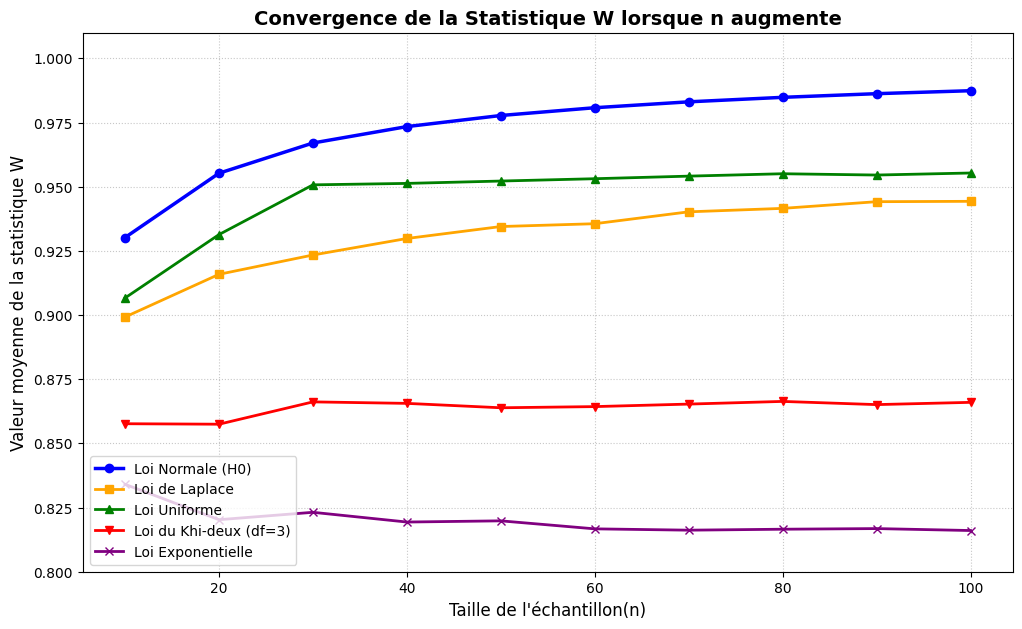

In [12]:
import os

tailles_n = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
Nsim = 5000

moyennes_normale = []
moyennes_laplace = []
moyennes_uniforme = []
moyennes_khi_deux = []
moyennes_exponentielle = []

n_valides = [] # Sécurité pour l'axe des abscisses

for n in tailles_n:
    try:
        # On charge les données
        a = np.loadtxt(f"{base_url}/a_n{n}.txt")
        scores_normale = np.loadtxt(f"{base_url}/W_n{n}.txt")

        moyennes_normale.append(np.mean(scores_normale))

        scores_laplace = []
        scores_uniforme = []
        scores_khi_deux = []
        scores_exponentielle = []

        for _ in range(Nsim):
            donnees_lap  = np.random.laplace(0, 1, n)
            donnees_uni  = np.random.uniform(0, 1, n)
            donnees_khi  = np.random.chisquare(df=3, size=n)
            donnees_exp  = np.random.exponential(1, n)

            #Calcule de la statistique w
            scores_laplace.append(Statistique_W(donnees_lap, a))
            scores_uniforme.append(Statistique_W(donnees_uni, a))
            scores_khi_deux.append(Statistique_W(donnees_khi, a))
            scores_exponentielle.append(Statistique_W(donnees_exp, a))

        moyennes_laplace.append(np.mean(scores_laplace))
        moyennes_uniforme.append(np.mean(scores_uniforme))
        moyennes_khi_deux.append(np.mean(scores_khi_deux))
        moyennes_exponentielle.append(np.mean(scores_exponentielle))

        n_valides.append(n)

    except OSError:
        print(f"Erreur: Les fichiers pour n={n} sont introuvables. Ce point sera ignoré.")

#  Tracé du graphique
if len(n_valides) > 0:
    plt.figure(figsize=(12, 7))

    plt.plot(n_valides, moyennes_normale,label="Loi Normale (H0)", color="blue",   marker="o", linewidth=2.5)
    plt.plot(n_valides, moyennes_laplace,label="Loi de Laplace", color="orange", marker="s", linewidth=2 )
    plt.plot(n_valides, moyennes_uniforme,label="Loi Uniforme", color="green",  marker="^", linewidth=2)
    plt.plot(n_valides, moyennes_khi_deux,label= "Loi du Khi-deux (df=3)", color="red",    marker="v", linewidth=2)
    plt.plot(n_valides, moyennes_exponentielle, label="Loi Exponentielle", color="purple", marker="x", linewidth=2)

    plt.title("Convergence de la Statistique W lorsque n augmente", fontsize=14, fontweight='bold')
    plt.xlabel("Taille de l'échantillon(n)", fontsize=12)
    plt.ylabel("Valeur moyenne de la statistique W", fontsize=12)
    plt.legend(loc='lower left')
    plt.grid(True, linestyle=':', alpha=0.7)

    # Limitation de l'axe Y pour bien voir le plafond à 1.0
    plt.ylim(0.80, 1.01)

    plt.savefig("images/Comvergence_W_lorsque_n_augmente.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Impossible de tracer le graphique: aucun fichier n'a été trouvé.")

### **Croisement entre les lois et les seuils critiques**

Ce graphique combine les valeurs moyennes de $W$ pour chaque loi avec les
seuils critiques du test à différents niveaux $\alpha$.

Nous voulons voir à partir de quel $n$ la courbe d'une loi entre dans une
**zone de rejet**, c'est-à-dire à partir de quel moment le test
arrive à détecter que les données ne sont pas normales.

Les trois seuils représentés sont :
- **$\alpha = 1\%$** : seuil strict, on rejette rarement
- **$\alpha = 5\%$** : seuil standard, le plus utilisé en pratique
- **$\alpha = 10\%$** : seuil large, on rejette plus facilement

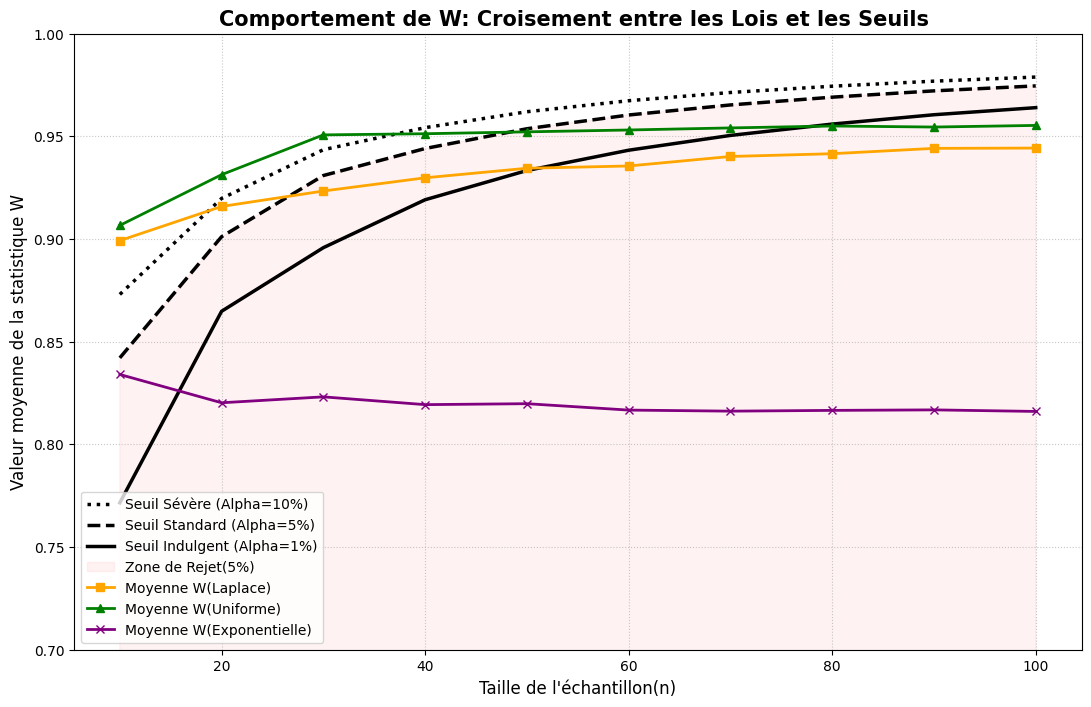

In [13]:
seuils_1_pct = []
seuils_5_pct = []
seuils_10_pct = []

for n in tailles_n:
    try:
        scores_normale = np.loadtxt(f"{base_url}/W_n{n}.txt")

        seuils_1_pct.append(np.quantile(scores_normale, 0.01))
        seuils_5_pct.append(np.quantile(scores_normale, 0.05))
        seuils_10_pct.append(np.quantile(scores_normale, 0.10))

    except OSError:
        print(f"Erreur: Les fichiers pour n={n} sont introuvables.")
        raise #Arrêt si fichier manquant

# Tracé du graphique
plt.figure(figsize=(13, 8))

plt.plot(tailles_n, seuils_10_pct, color='black', linestyle=':',  linewidth=2.5, label="Seuil Sévère (Alpha=10%)")
plt.plot(tailles_n, seuils_5_pct,  color='black', linestyle='--', linewidth=2.5, label="Seuil Standard (Alpha=5%)")
plt.plot(tailles_n, seuils_1_pct,  color='black', linestyle='-',  linewidth=2.5, label="Seuil Indulgent (Alpha=1%)")


plt.fill_between(tailles_n, 0.60, seuils_5_pct, color='red', alpha=0.05, label="Zone de Rejet(5%)")


plt.plot(tailles_n, moyennes_laplace,       label="Moyenne W(Laplace)",       color="orange", marker="s", linewidth=2)
plt.plot(tailles_n, moyennes_uniforme,      label="Moyenne W(Uniforme)",      color="green",  marker="^", linewidth=2)
plt.plot(tailles_n, moyennes_exponentielle, label="Moyenne W(Exponentielle)", color="purple", marker="x", linewidth=2)


plt.title("Comportement de W: Croisement entre les Lois et les Seuils ", fontsize=15, fontweight='bold')
plt.xlabel("Taille de l'échantillon(n)", fontsize=12)
plt.ylabel("Valeur moyenne de la statistique W", fontsize=12)

plt.ylim(0.70, 1.0)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)

plt.savefig("images/croisement_lois_seuil.png", dpi=300, bbox_inches='tight')
plt.show()

## **5.Table des quantiles**

### **Génération de la table des quantiles**

À partir des valeurs simulées de la statistique $W$, nous avons calculé et sauvegardé les quantiles correspondants pour différents niveaux de risque alpha et pour chaque taille d'échantillon n.

> **Note :** Cette cellule a déjà été exécutée et les fichiers sont disponibles
> sur GitHub:
https://github.com/shapiroMIGS/shapiro-wilk/blob/main/Table_Quantiles_Shapiro_annexe.csv

 Il n'est donc pas nécessaire de la relancer.

In [4]:
import pandas as pd
from tqdm import tqdm

# Paramètres
#tailles_n= [3, 4, 5,6, 7,8, 9, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100] # Tailles clés pour le  rapport
tailles_n= tailles_n= range(3, 101) # Pour avoir la table complète
niveaux = [0.01, 0.02, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]


resultats_quantiles = []
for n in tqdm(tailles_n, desc="Calcul par taille n"):
    try:
        # Chargement
        W_simules = np.loadtxt(f"{base_url}/W_n{n}.txt")

        # Calcul des quantiles
        valeurs_quantiles = np.quantile(W_simules, niveaux)

        # Création d'un dictionnaire ligne
        ligne = {"n": n}  # initialisation avec n
        for niveau, val in zip(niveaux, valeurs_quantiles):
            ligne[f"{niveau:.2f}"] = val  #construction de chaque ligne du tableau

        resultats_quantiles.append(ligne)

    except OSError:
            print(f"Fichiers manquants pour n={n}")

# Création du tableau final avec Pandas
df_quantiles = pd.DataFrame(resultats_quantiles)
df_quantiles.set_index("n", inplace=True)

df_quantiles = df_quantiles.round(4)

#Affichage
print("TABLE DES QUANTILES DE LA STATISTIQUE W")
print("-"*70)
print(df_quantiles) #les valeurs avec 4 ou 5 décimales

#Exportation
df_quantiles.to_csv("Table_Quantiles_Shapiro.csv")

Calcul par taille n: 100%|██████████| 98/98 [00:21<00:00,  4.61it/s]

TABLE DES QUANTILES DE LA STATISTIQUE W
----------------------------------------------------------------------
       0.01    0.02    0.05    0.10    0.50    0.90    0.95    0.99
n                                                                  
3    0.7544  0.7589  0.7722  0.7939  0.9328  0.9970  0.9993  1.0017
4    0.6793  0.7049  0.7523  0.7994  0.9181  0.9834  0.9917  0.9984
5    0.6721  0.7121  0.7689  0.8118  0.9195  0.9765  0.9880  1.0084
6    0.7009  0.7376  0.7886  0.8288  0.9253  0.9728  0.9809  0.9915
7    0.7200  0.7558  0.8046  0.8417  0.9295  0.9721  0.9796  0.9893
..      ...     ...     ...     ...     ...     ...     ...     ...
96   0.9628  0.9675  0.9736  0.9782  0.9886  0.9938  0.9947  0.9961
97   0.9629  0.9677  0.9738  0.9783  0.9887  0.9938  0.9948  0.9961
98   0.9633  0.9681  0.9741  0.9786  0.9888  0.9939  0.9948  0.9961
99   0.9637  0.9684  0.9744  0.9788  0.9889  0.9939  0.9948  0.9962
100  0.9640  0.9687  0.9746  0.9789  0.9890  0.9940  0.9949  0.9962

[98 

### **Comparaison avec la table de l'article**

Pour valider nos simulations, nous avons comparé les quantiles obtenus avec ceux de Shapiro & Wilk (1965).

   n |  alpha |  SW 1965 |   Simulé |   Erreur
---------------------------------------------
   3 |   0.01 |   0.7530 |   0.7544 |   0.0014
   3 |   0.02 |   0.7560 |   0.7589 |   0.0029
   3 |   0.05 |   0.7670 |   0.7722 |   0.0052
   3 |   0.10 |   0.7890 |   0.7939 |   0.0049
   3 |   0.50 |   0.9590 |   0.9328 |   0.0262
   3 |   0.90 |   0.9980 |   0.9970 |   0.0010
   3 |   0.95 |   0.9990 |   0.9993 |   0.0003
   3 |   0.99 |   1.0000 |   1.0017 |   0.0017

   4 |   0.01 |   0.6870 |   0.6793 |   0.0077
   4 |   0.02 |   0.7070 |   0.7049 |   0.0021
   4 |   0.05 |   0.7480 |   0.7523 |   0.0043
   4 |   0.10 |   0.7920 |   0.7994 |   0.0074
   4 |   0.50 |   0.9350 |   0.9181 |   0.0169
   4 |   0.90 |   0.9870 |   0.9834 |   0.0036
   4 |   0.95 |   0.9920 |   0.9917 |   0.0003
   4 |   0.99 |   0.9960 |   0.9984 |   0.0024

   5 |   0.01 |   0.6860 |   0.6721 |   0.0139
   5 |   0.02 |   0.7150 |   0.7121 |   0.0029
   5 |   0.05 |   0.7620 |   0.7689 |   0.0069
   5 |   0.1

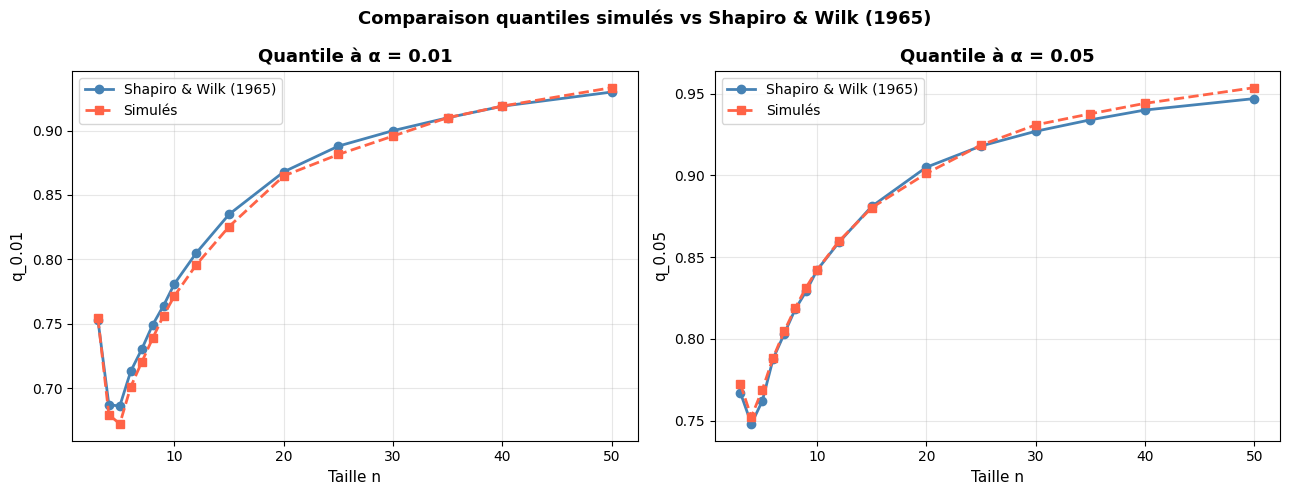

In [5]:
# Table 6 de Shapiro & Wilk (1965)
# alpha : 0.01  0.02  0.05  0.10  0.50  0.90  0.95  0.99
table_sw_1965 = {
     3: [0.753, 0.756, 0.767, 0.789, 0.959, 0.998, 0.999, 1.000],
     4: [0.687, 0.707, 0.748, 0.792, 0.935, 0.987, 0.992, 0.996],
     5: [0.686, 0.715, 0.762, 0.806, 0.927, 0.979, 0.986, 0.991],
     6: [0.713, 0.743, 0.788, 0.826, 0.927, 0.974, 0.981, 0.986],
     7: [0.730, 0.760, 0.803, 0.838, 0.928, 0.972, 0.979, 0.985],
     8: [0.749, 0.778, 0.818, 0.851, 0.932, 0.972, 0.978, 0.984],
     9: [0.764, 0.791, 0.829, 0.859, 0.935, 0.972, 0.978, 0.984],
    10: [0.781, 0.806, 0.842, 0.869, 0.938, 0.972, 0.978, 0.983],
    12: [0.805, 0.828, 0.859, 0.883, 0.943, 0.973, 0.979, 0.984],
    15: [0.835, 0.855, 0.881, 0.901, 0.950, 0.975, 0.980, 0.984],
    20: [0.868, 0.884, 0.905, 0.920, 0.959, 0.979, 0.983, 0.986],
    25: [0.888, 0.901, 0.918, 0.931, 0.964, 0.981, 0.985, 0.988],
    30: [0.900, 0.912, 0.927, 0.939, 0.967, 0.983, 0.985, 0.988],
    35: [0.910, 0.920, 0.934, 0.944, 0.969, 0.984, 0.986, 0.989],
    40: [0.919, 0.928, 0.940, 0.949, 0.972, 0.985, 0.987, 0.989],
    50: [0.930, 0.938, 0.947, 0.955, 0.974, 0.985, 0.988, 0.990],
}




niveaux      = [0.01, 0.02, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]
tailles_comp = [n for n in table_sw_1965 if n in df_quantiles.index]

# Affichage du tableau de comparaison
print(f"{'n':>4} | {'alpha':>6} | {'SW 1965':>8} | {'Simulé':>8} | {'Erreur':>8}")
print("-" * 45)

for n in tailles_comp:
    for i, alpha in enumerate(niveaux):
        sw  = table_sw_1965[n][i]
        sim = df_quantiles.loc[n, f"{alpha:.2f}"]
        err = abs(sim - sw)
        print(f"{n:>4} | {alpha:>6.2f} | {sw:>8.4f} | {sim:>8.4f} | {err:>8.4f}")
    print()

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, alpha, col in zip(axes, [0.01, 0.05], ["0.01", "0.05"]):
    sw_vals  = [table_sw_1965[n][niveaux.index(alpha)] for n in tailles_comp]
    sim_vals = [df_quantiles.loc[n, col] for n in tailles_comp]

    ax.plot(tailles_comp, sw_vals,  'o-',  color='steelblue', lw=2, label='Shapiro & Wilk (1965)')
    ax.plot(tailles_comp, sim_vals, 's--', color='tomato',    lw=2, label='Simulés')
    ax.set_title(f"Quantile à α = {alpha}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Taille n", fontsize=11)
    ax.set_ylabel(f"q_{alpha}", fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Comparaison quantiles simulés vs Shapiro & Wilk (1965)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("images/comparaison_quantiles.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
erreurs = []

for n in table_sw_1965:
    if n not in df_quantiles.index:
        continue
    for i, alpha in enumerate(niveaux):
        val_sw  = table_sw_1965[n][i]
        val_sim = df_quantiles.loc[n, f"{alpha:.2f}"]
        erreurs.append(abs(val_sim - val_sw))

erreurs = np.array(erreurs)
print(f"Erreur moyenne  : {np.mean(erreurs):.4f}")
print(f"Erreur maximale : {np.max(erreurs):.4f}")
print(f"Erreur minimale : {np.min(erreurs):.6f}")

Erreur moyenne  : 0.0040
Erreur maximale : 0.0262
Erreur minimale : 0.000000


Les quantiles simulés sont très proches de ceux de Shapiro & Wilk (1965).
 L'erreur moyenne de 0.004 montre que notre simulation est fiable.
 L'erreur maximale de 0.026 s'observe pour les petits n et les quantiles
 extrêmes (alpha=1%), ce qui est normal car les événements rares sont
 plus difficiles à estimer par simulation.
 Dans l'ensemble, nos résultats confirment que notre implémentation est correcte.

# **6. Test de Shapiro-Wilk simplifié**

Afin de réaliser des tests, nous avons développé une fonction simplifiée du test de Shapiro-Wilk qui calcule la
statistique $Wobs$ à partir des données observées.

Ensuite, elle évalue la p-valeur empirique.

En fonction de cette p-valeur et du niveau de risque alpha (fixé à 5% par défaut), le test rejette ou
conserve l’hypothèse nulle H_0.

In [ ]:
def shapiro_wilk_test_simplifie(donnees):
    n = len(donnees)

    if n<3 or n>100:
        raise ValueError(f"Erreur:La taille de l'échantillon (n={n}) n'est pas couverte par notre base(n entre 3 et 100).")

    try:
      a= np.loadtxt(f"{base_url}/a_n{n}.txt")
      W_simules= np.loadtxt(f"{base_url}/W_n{n}.txt")

    except OSError:
      print(f"Erreur: Les fichiers pour n={n} sont introuvables.")
      raise #Arrêt si fichier manquant

    # Calcul du W observé sur nos données
    W_obs=Statistique_W(donnees, a)

    # Calcul de la p-valeur empirique: proportion de W simulés <= W_obs
    p_valeur_empirique = np.mean(W_simules <= W_obs)

    return W_obs, p_valeur_empirique


def decision_test_shapiro(W_obs, p_valeur_empirique, alpha=0.05):

    print(" RÉSULTATS DU TEST DE SHAPIRO-WILK")
    print("-" * 50)
    print(f"Niveau de risque (alpha)   : {alpha}")
    print("-" * 50)
    print(f"Statistique W observée     : {W_obs:.5f}")
    print(f"P-valeur Empirique   : {p_valeur_empirique:.5f}")
    print("-" * 50)

    # La décision est maintenant prise grâce à VOTRE p-valeur empirique
    if p_valeur_empirique >= alpha:

        print("Décision: On conserve H0.")
        print("-> Il n'y a pas de preuves suffisantes pour rejeter la normalité.")
        print("-> On garde l'hypothèse nulle, nos données suivent une loi normale.")
    else:
        print("Décision: On rejette H0.")
        print("-> La p-valeur empirique est inférieure à alpha.")
        print("-> Les données ne suivent pas une loi normale.")


    return  p_valeur_empirique

# **7. Etude de la puissance**
*Table 7 (page 608)*


Pour évaluer l'efficacité du test de Shapiro-Wilk, nous avons étudié sa puissance face au différentes lois vues plus haut. Cette analyse nous permet de déterminer dans quelle point le test est capable de détecter des écarts à la normalité selon les caractéristiques des données.

Loi uniforme
n= 10  Puissance: 7.0%
n= 20  Puissance: 11.2%
n= 30  Puissance: 17.0%
n= 40  Puissance: 30.7%
n= 50  Puissance: 47.4%
n= 60  Puissance: 65.1%
n= 70  Puissance: 78.9%
n= 80  Puissance: 86.0%
n= 90  Puissance: 94.6%
n=100  Puissance: 97.0%

Loi de Laplace
n= 10  Puissance: 18.0%
n= 20  Puissance: 30.4%
n= 30  Puissance: 43.4%
n= 40  Puissance: 51.5%
n= 50  Puissance: 58.7%
n= 60  Puissance: 65.5%
n= 70  Puissance: 70.9%
n= 80  Puissance: 76.2%
n= 90  Puissance: 80.9%
n=100  Puissance: 83.1%

Loi Exponentielle
n= 10  Puissance: 44.5%
n= 20  Puissance: 83.6%
n= 30  Puissance: 95.4%
n= 40  Puissance: 99.0%
n= 50  Puissance: 99.9%
n= 60  Puissance: 100.0%
n= 70  Puissance: 100.0%
n= 80  Puissance: 100.0%
n= 90  Puissance: 100.0%
n=100  Puissance: 100.0%


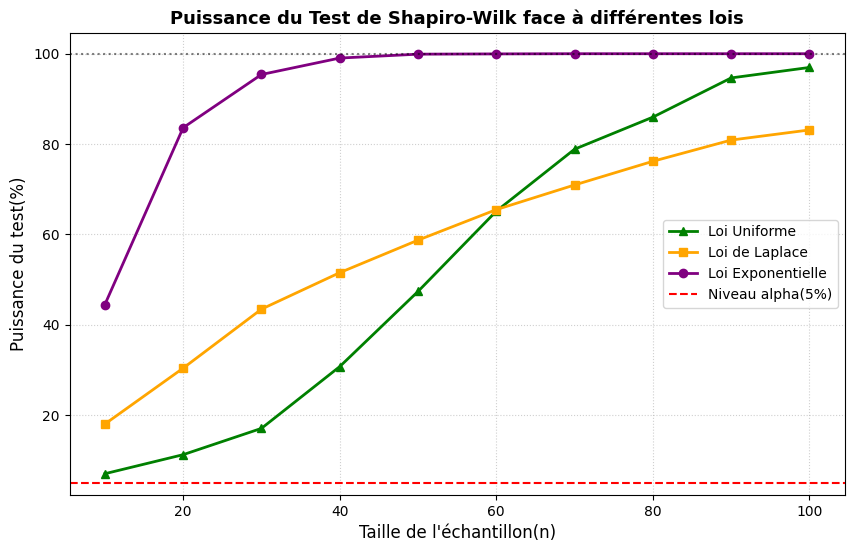

In [14]:
def puissance_test(fonction, tailles_n, Nsim=5000, alpha=0.05):
    puissances = []

    for n in tailles_n:
        try:
            a = np.loadtxt(f"{base_url}/a_n{n}.txt")
            W_simules_H0 = np.loadtxt(f"{base_url}/W_n{n}.txt")

            # Le seuil en dessous duquel on rejette H0
            seuil = np.quantile(W_simules_H0, alpha)

            rejets = 0
            for _ in range(Nsim):
                x= fonction(n)
                if Statistique_W(x, a) < seuil:
                    rejets += 1

            puissance=rejets/Nsim*100
            puissances.append(puissance)
            print(f"n={n:3d}  Puissance: {puissance:.1f}%")

        except OSError:
            print(f"Fichiers manquants pour n={n}")

    return puissances



#Test

tailles_n = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

print("Loi uniforme")
puissance_uni  = puissance_test(lambda n: np.random.uniform(0, 1, n), tailles_n)
print("\nLoi de Laplace")
puissance_lap  = puissance_test(lambda n: np.random.laplace(0, 1, n), tailles_n)
print("\nLoi Exponentielle")
puissance_expo = puissance_test(lambda n: np.random.exponential(1, n), tailles_n)

plt.figure(figsize=(10, 6))
plt.plot(tailles_n, puissance_uni,  color='green',  marker='^', linewidth=2, label="Loi Uniforme")
plt.plot(tailles_n, puissance_lap,  color='orange', marker='s', linewidth=2, label="Loi de Laplace")
plt.plot(tailles_n, puissance_expo, color='purple', marker='o', linewidth=2, label="Loi Exponentielle")

plt.axhline(y=100, color='black', linestyle=':', alpha=0.5)
plt.axhline(y=5, color='red', linestyle='--', label="Niveau alpha(5%)")

plt.title("Puissance du Test de Shapiro-Wilk face à différentes lois", fontsize=13, fontweight='bold')
plt.xlabel("Taille de l'échantillon(n)", fontsize=12)
plt.ylabel("Puissance du test(%)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("images/puissance_test.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Table de puissance pour n = 20, alpha = 5%
n_fixe = 20
Nsim   = 5000

a=np.loadtxt(f"{base_url}/a_n{n_fixe}.txt")
W_simules_H0=np.loadtxt(f"{base_url}/W_n{n_fixe}.txt")[:10000]
seuil=np.quantile(W_simules_H0, 0.05)

lois = {
    "Exponentielle Exp(1)" : lambda n: np.random.exponential(1, n),
    "Uniforme U(0,1)"      : lambda n: np.random.uniform(0, 1, n),
    "Laplace(0,1)"         : lambda n: np.random.laplace(0, 1, n),
    "Khi-deux (df=3)"      : lambda n: np.random.chisquare(3, n),
}

print(f"Puissance du test pour n={n_fixe}, alpha=5%")
print("-" * 40)

for nom, loi in lois.items():
    rejets = sum(1 for _ in range(Nsim) if Statistique_W(loi(n_fixe), a) < seuil)
    puissance = rejets / Nsim * 100
    print(f"{nom:<25} : {puissance:.1f}%")

Puissance du test pour n=20, alpha=5%
----------------------------------------
Exponentielle Exp(1)      : 82.6%
Uniforme U(0,1)           : 11.8%
Laplace(0,1)              : 32.5%
Khi-deux (df=3)           : 66.6%


### **Calcul du taux de non rejet loi uniforme**
Comme la loi uniforme est la plus difficile à détecter, nous avons calculé
le taux d'erreur de type II


Erreur type II loi uniforme
[92.58 87.68 82.7  69.42 51.2  35.   21.08 13.6   5.7   2.8 ]


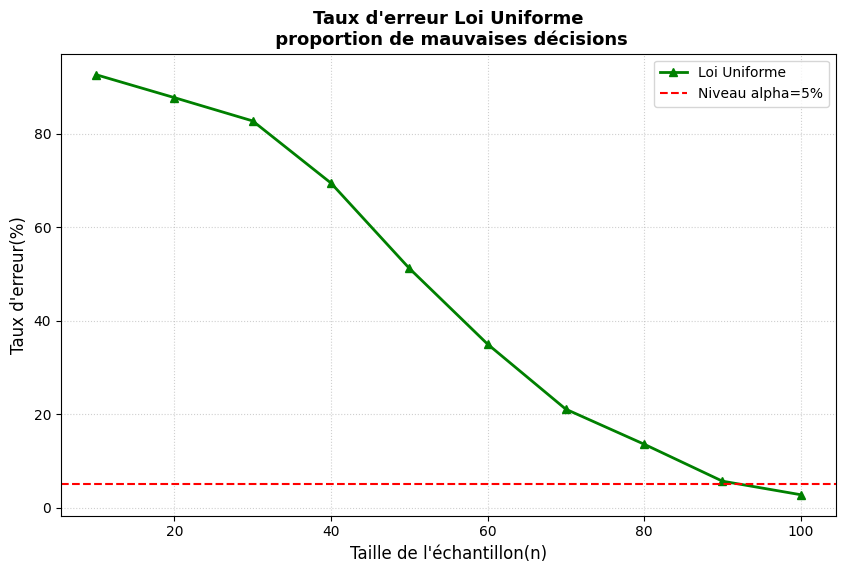

In [ ]:
erreur_type_2_uni = 100 - np.array(puissance_uni)
print("\nErreur type II loi uniforme")
print(erreur_type_2_uni)


plt.figure(figsize=(10, 6))
plt.plot(tailles_n, erreur_type_2_uni, color='green', marker='^',linewidth=2, label="Loi Uniforme")
plt.axhline(y=5, color='red', linestyle='--', label="Niveau alpha=5%")
plt.title("Taux d'erreur Loi Uniforme\n proportion de mauvaises décisions",fontsize=13, fontweight='bold')
plt.xlabel("Taille de l'échantillon(n)", fontsize=12)
plt.ylabel("Taux d'erreur(%)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("images/erreur_type2_uniforme.png", dpi=300, bbox_inches='tight')
plt.show()


# **8. Application**

### **Application sur données réelles — Iris de Fisher**

Pour illustrer l'utilisation concrète du test, nous l'appliquons à un jeu de données réel :
les mesures de longueur des sépales de l'espèce *Iris setosa* issues du célèbre jeu de données
de Fisher (1936), composé de 50 observations.

n = 50
Moyenne : 5.0060
Ecart-type : 0.3489
 RÉSULTATS DU TEST DE SHAPIRO-WILK
--------------------------------------------------
Niveau de risque (alpha)   : 0.05
--------------------------------------------------
Statistique W observée     : 0.97876
P-valeur Empirique   : 0.42343
--------------------------------------------------
Décision: On conserve H0.
-> Il n'y a pas de preuves suffisantes pour rejeter la normalité.
-> On garde l'hypothèse nulle, nos données suivent une loi normale.


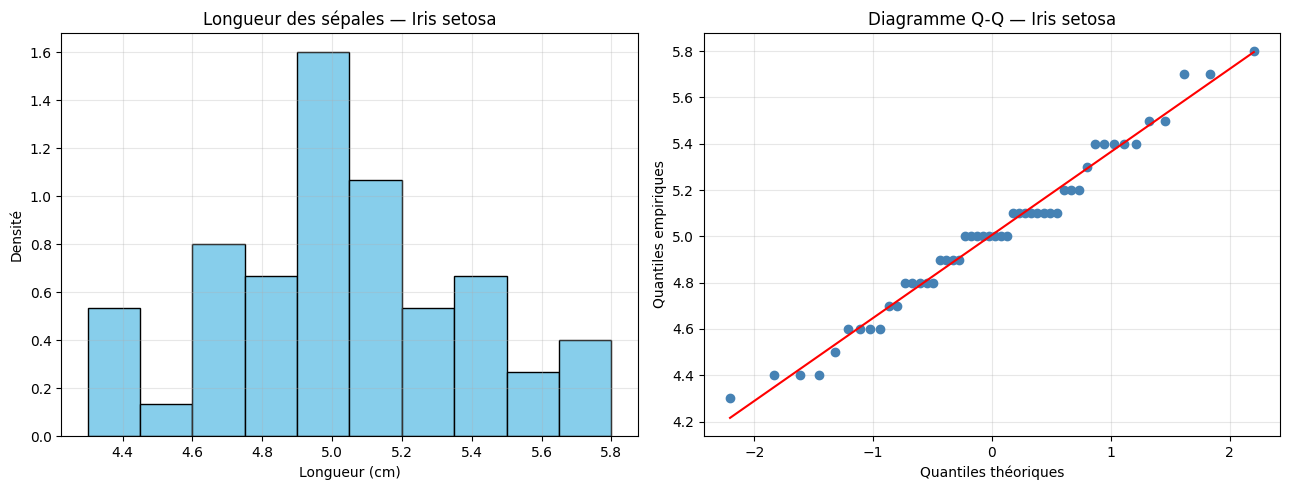

In [ ]:
from sklearn.datasets import load_iris
import numpy as np

# Chargement des données
iris = load_iris()

# On prend la longueur des sépales de l'espèce Iris setosa (n=50)
donnees_iris = iris.data[:50, 0]  # colonne 0 = longueur des sépales

print(f"n = {len(donnees_iris)}")
print(f"Moyenne : {np.mean(donnees_iris):.4f}")
print(f"Ecart-type : {np.std(donnees_iris):.4f}")

# Test de Shapiro-Wilk
W, p = shapiro_wilk_test_simplifie(donnees_iris)
decision_test_shapiro(W, p)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme
axes[0].hist(donnees_iris, bins=10, density=True, color='skyblue', edgecolor='black')
axes[0].set_title("Longueur des sépales — Iris setosa")
axes[0].set_xlabel("Longueur (cm)")
axes[0].set_ylabel("Densité")
axes[0].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(donnees_iris, dist="norm")
axes[1].plot(osm, osr, 'o', color='steelblue')
axes[1].plot(osm, slope*osm + intercept, 'r-')
axes[1].set_title("Diagramme Q-Q — Iris setosa")
axes[1].set_xlabel("Quantiles théoriques")
axes[1].set_ylabel("Quantiles empiriques")
axes[1].grid(True, alpha=0.3)

plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.savefig("images/iris_setosa.png", dpi=300, bbox_inches='tight')
plt.show()

### **Application sur les lois classiques vues plus haut**

##### **1. Loi Normale pour la vérification**

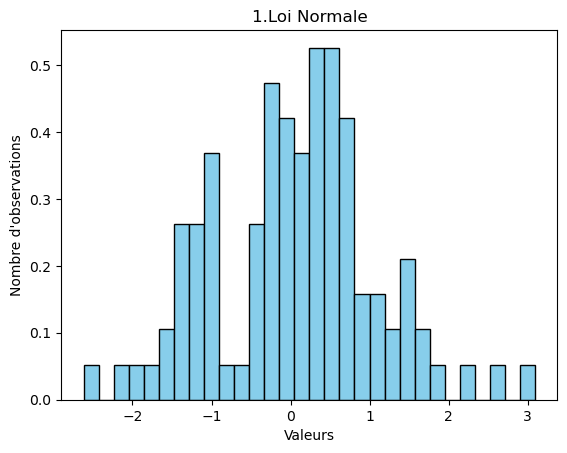

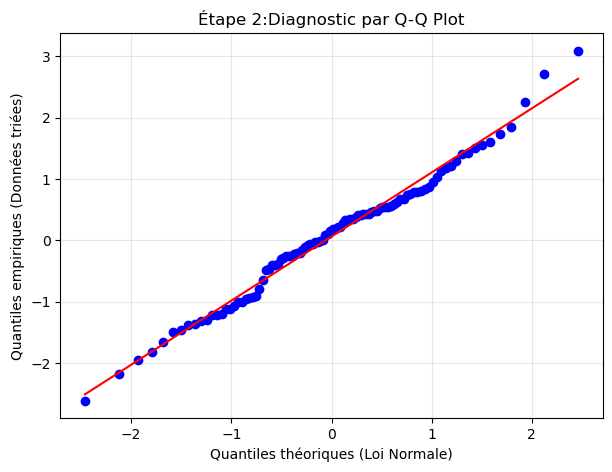

 RÉSULTATS DU TEST DE SHAPIRO-WILK
--------------------------------------------------
Niveau de risque (alpha)   : 0.05
--------------------------------------------------
Statistique W observée     : 0.98695
P-valeur Empirique   : 0.36653
--------------------------------------------------
Décision: On conserve H0.
-> Il n'y a pas de preuves suffisantes pour rejeter la normalité.
-> On garde l'hypothèse nulle, nos données suivent une loi normale.


np.float64(0.366532)

In [ ]:
#Paramètre
n= 100

# 1. Loi Normale
donnees_normale = np.random.normal(0, 1, n)
tracer_histogramme(
        donnees=donnees_normale,
        bins=30,
        densite=True,
        titre="1.Loi Normale",
        ylabel="Nombre d'observations"
    )
tracer_qq_plot(donnees_normale, titre="Étape 2:Diagnostic par Q-Q Plot")
W, p = shapiro_wilk_test_simplifie(donnees_normale)
decision_test_shapiro(W, p)

##### **2.Loi Uniforme**

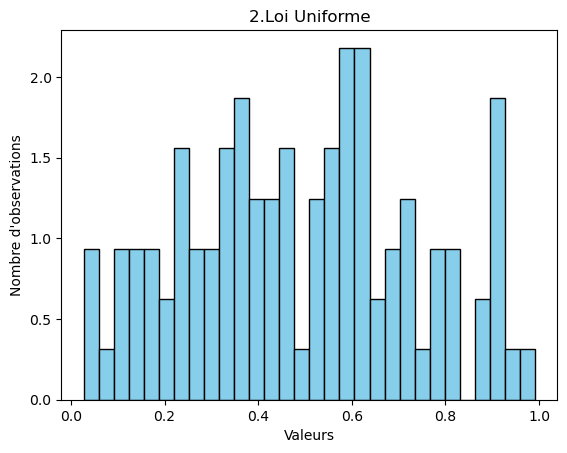

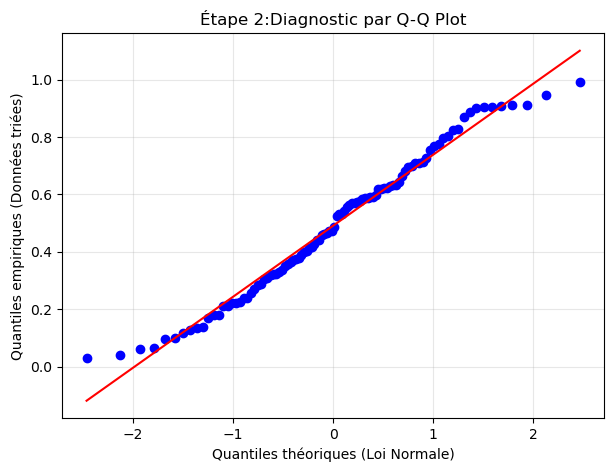

 RÉSULTATS DU TEST DE SHAPIRO-WILK
--------------------------------------------------
Niveau de risque (alpha)   : 0.05
--------------------------------------------------
Statistique W observée     : 0.98198
P-valeur Empirique   : 0.16492
--------------------------------------------------
Décision: On conserve H0.
-> Il n'y a pas de preuves suffisantes pour rejeter la normalité.
-> On garde l'hypothèse nulle, nos données suivent une loi normale.


np.float64(0.164921)

In [ ]:
donnees_uniforme = np.random.uniform(0, 1, n)
tracer_histogramme(
        donnees=donnees_uniforme,
        bins=30,
        densite=True,
        titre="2.Loi Uniforme",
        ylabel="Nombre d'observations"
    )
tracer_qq_plot(donnees_uniforme, titre="Étape 2:Diagnostic par Q-Q Plot")
W, p = shapiro_wilk_test_simplifie(donnees_uniforme)
decision_test_shapiro(W, p)

##### **3. Loi de Laplace**


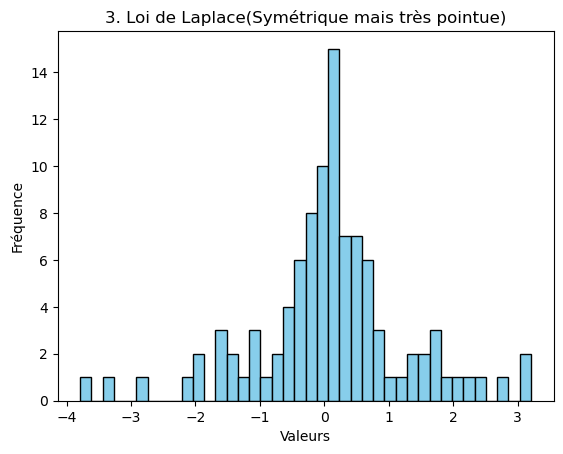

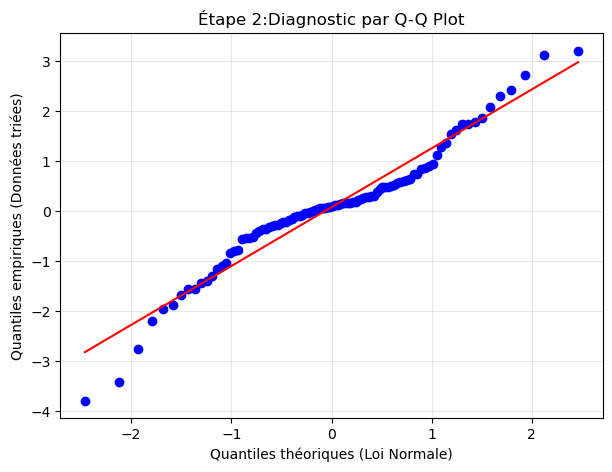

 RÉSULTATS DU TEST DE SHAPIRO-WILK
--------------------------------------------------
Niveau de risque (alpha)   : 0.05
--------------------------------------------------
Statistique W observée     : 0.94954
P-valeur Empirique   : 0.00126
--------------------------------------------------
Décision: On rejette H0.
-> La p-valeur empirique est inférieure à alpha.
-> Les données ne suivent pas une loi normale.


np.float64(0.001261)

In [ ]:
# 3. Loi de Laplace
donnees_laplace = np.random.laplace(0,1, n)
tracer_histogramme(
        donnees=donnees_laplace,
        bins=40,
        densite=False,
        titre="3. Loi de Laplace(Symétrique mais très pointue)"
    )
tracer_qq_plot(donnees_laplace, titre="Étape 2:Diagnostic par Q-Q Plot")
W, p = shapiro_wilk_test_simplifie(donnees_laplace)
decision_test_shapiro(W, p)

##### **4. Loi Exponentielle (Test en mode Densité de probabilité)**

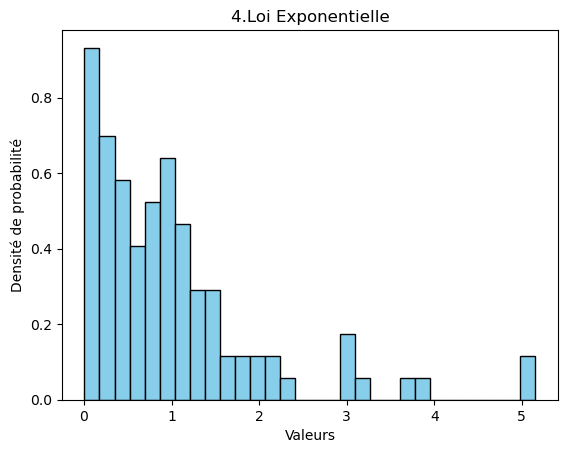

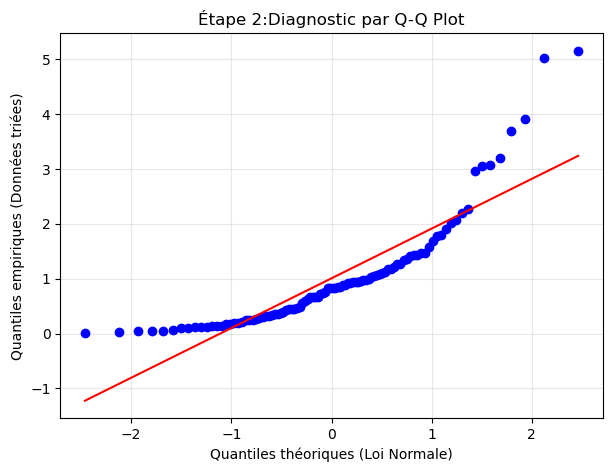

 RÉSULTATS DU TEST DE SHAPIRO-WILK
--------------------------------------------------
Niveau de risque (alpha)   : 0.05
--------------------------------------------------
Statistique W observée     : 0.78773
P-valeur Empirique   : 0.00000
--------------------------------------------------
Décision: On rejette H0.
-> La p-valeur empirique est inférieure à alpha.
-> Les données ne suivent pas une loi normale.


np.float64(0.0)

In [ ]:
# 3. Loi Exponentielle (Test en mode Densité de probabilité)
donnees_exponentielle = np.random.exponential(1, n)
tracer_histogramme(
        donnees=donnees_exponentielle,
        bins=30,
        densite=True,
        titre="4.Loi Exponentielle",
        ylabel="Densité de probabilité"
    )
tracer_qq_plot(donnees_exponentielle, titre="Étape 2:Diagnostic par Q-Q Plot")
W, p = shapiro_wilk_test_simplifie(donnees_exponentielle)
decision_test_shapiro(W, p)